=== Built-in Method ===
Accuracy: 0.9766081871345029
Error Rate: 0.023391812865497075
AUC: 0.9976484420928865


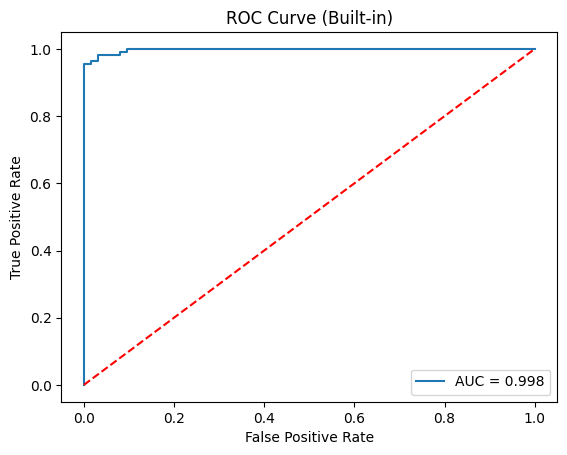

In [ ]:
#Using methods

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score

# Load in-built dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print("=== Built-in Method ===")
print("Accuracy:", accuracy)
print("Error Rate:", error)
print("AUC:", roc_auc)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Built-in)")
plt.legend()
plt.show()


=== Manual Method ===
Accuracy: 0.9766081871345029
Error Rate: 0.023391812865497075
AUC: 0.9976484420928865


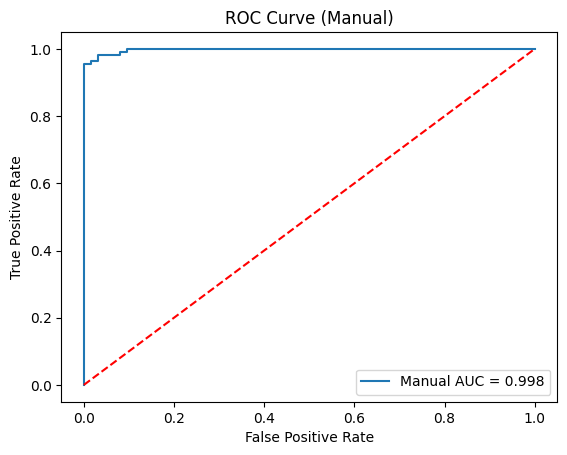

In [ ]:
#Manual

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

# Accuracy
correct = 0
for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        correct += 1

accuracy_manual = correct / len(y_test)
error_manual = 1 - accuracy_manual

# ROC + AUC
def manual_roc_auc(y_true, y_scores):
    desc_score_indices = np.argsort(-y_scores)
    y_scores = y_scores[desc_score_indices]
    y_true = y_true[desc_score_indices]

    P = sum(y_true)
    N = len(y_true) - P

    tpr = []
    fpr = []
    tp = 0
    fp = 0

    for i in range(len(y_scores)):
        if y_true[i] == 1:
            tp += 1
        else:
            fp += 1

        tpr.append(tp / P)
        fpr.append(fp / N)

    tpr = [0] + tpr
    fpr = [0] + fpr

    auc_value = 0
    for i in range(1, len(tpr)):
        auc_value += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2

    return fpr, tpr, auc_value

fpr_manual, tpr_manual, auc_manual = manual_roc_auc(y_test, y_scores)

print("\n=== Manual Method ===")
print("Accuracy:", accuracy_manual)
print("Error Rate:", error_manual)
print("AUC:", auc_manual)

# Plot ROC
plt.figure()
plt.plot(fpr_manual, tpr_manual, label=f'Manual AUC = {auc_manual:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Manual)")
plt.legend()
plt.show()